# OU process - Work sheet
## OU process basic information
Consider the OU process

$$
dx_t = -\beta x_t dt + \sigma dW_t, \quad x(0) \sim p_0(x_0).
$$

The solution is

$$
x_t = \mu_t(x_0) + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1),
$$

where

$$
\mu_t(x_0) = e^{-\beta t} x_0, \quad \sigma_t^2 = \frac{\sigma^2}{2\beta}(1 - e^{-2\beta t}).
$$

So, given a terminal time $T$, we can generate $x_t$, for $t \in [0, T]$.

# 1. Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 建議用 GPU

batch_size = 2048

def sample_line(n_points):
    slope = 0.4
    intercept = -5.0
    x = np.random.uniform(-6, 6, size=n_points)
    noise = np.random.randn(n_points) * 0.2   
    y = slope * x + intercept + noise
    return np.stack([x, y], axis=1)

def sample_blob(n_points):
    mu = np.array([-5, 0])
    C = np.eye(2) * 1.0
    return mu + np.random.multivariate_normal([0,0], C, size=n_points)

def sample_p0_mix(n_blob=3000, n_line=2000):
    blob = sample_blob(n_blob)
    line = sample_line(n_line)
    data = np.concatenate([blob, line], axis=0)
    np.random.shuffle(data)
    return data

def marginal_prob_std(t, beta_min=0.1, beta_max=20.0):
    log_mean_coeff = -0.25 * t ** 2 * (beta_max - beta_min) - 0.5 * t * beta_min
    mean = torch.exp(log_mean_coeff)
    std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))
    return mean, std


In [2]:
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ScoreNet_SDE(nn.Module):
    def __init__(self, x_dim, hidden):
        super().__init__()
        self.embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=hidden),
            nn.Linear(hidden, hidden),
            nn.SiLU()
        )
        self.fc1 = nn.Linear(x_dim, hidden)
        self.layers = nn.ModuleList()
        for _ in range(3):
            self.layers.append(nn.Linear(hidden, hidden))
        self.fc_out = nn.Linear(hidden, x_dim)
        self.act = nn.SiLU()

    def forward(self, x, t):
        t_embed = self.embed(t)
        h = self.fc1(x)
        h = h + t_embed
        h = self.act(h)
        for layer in self.layers:
            h = self.act(layer(h)) 
        
        # Output: noise
        return self.fc_out(h)

def sde_dsm_loss(model, x0):
    batch_size = x0.shape[0]
    t = torch.rand(batch_size, device=x0.device) * (1. - 1e-5) + 1e-5
    
    mean, std = marginal_prob_std(t)
    mean = mean.view(-1, 1)
    std = std.view(-1, 1)
    
    noise = torch.randn_like(x0) 
    xt = mean * x0 + std * noise
    
    noise_pred = model(xt, t)
    
    loss = torch.mean(torch.sum((noise_pred - noise)**2, dim=1))
    return loss

In [3]:
# =========== Training Loop ===========
model = ScoreNet_SDE(x_dim=2, hidden=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Start SDE Training...")
n_step = 5000
loss_history = []

for step in range(1, n_step+1):
    x0_np = sample_p0_mix(batch_size//2, batch_size - batch_size//2).astype(np.float32)
    x0 = torch.from_numpy(x0_np).to(device)
    
    model.train()
    loss = sde_dsm_loss(model, x0)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    loss_history.append(loss.item())
    if step % 500 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.6f}")


Start SDE Training...
Step  500 | Loss: 0.675715
Step 1000 | Loss: 0.696034
Step 1500 | Loss: 0.679367
Step 2000 | Loss: 0.727099
Step 2500 | Loss: 0.627563
Step 3000 | Loss: 0.689138
Step 3500 | Loss: 0.707374
Step 4000 | Loss: 0.719121
Step 4500 | Loss: 0.665259
Step 5000 | Loss: 0.648313


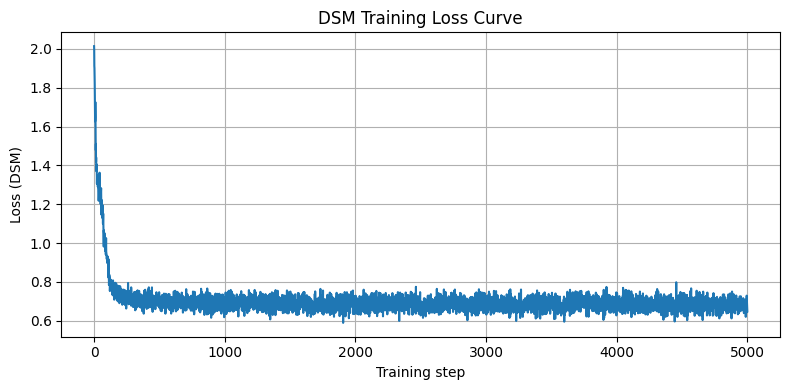

In [4]:
import matplotlib.pyplot as plt

def plot_loss_curve(loss_list):
    """
    loss_list: Python list or Tensor containing loss values for each step
    """
    plt.figure(figsize=(8,4))
    plt.plot(loss_list, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("Loss (DSM)")
    plt.title("DSM Training Loss Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_loss_curve(loss_history)

# 2. Reverse

In [ ]:
# =========== 5. Sampling (Reverse SDE) ===========
# 這是驗證模型是否有效的關鍵步驟

def get_beta_schedule(t, beta_min=0.1, beta_max=20.0):
    # 這是對應你 marginal_prob_std 的 beta(t) 函數
    # 因為 mean = exp(-0.25 * t^2 * (max-min) - 0.5 * t * min)
    # 這是 Linear Beta Schedule: beta(t) = beta_min + t * (beta_max - beta_min)
    return beta_min + t * (beta_max - beta_min)

@torch.no_grad()
def p_sample_loop(model, shape, n_steps=1000):
    device = next(model.parameters()).device
    x = torch.randn(shape, device=device)
    time_steps = torch.linspace(1., 1e-3, n_steps + 1, device=device)
    
    for i in range(n_steps):
        t_current = time_steps[i]
        t_next = time_steps[i+1]
        dt = t_current - t_next 
        
        # 取得當下的 std
        _, std_t = marginal_prob_std(torch.tensor([t_current], device=device))
        beta_t = get_beta_schedule(t_current)
        
        batch_t = torch.ones(shape[0], device=device) * t_current
        
        # 【重要修改】模型預測 epsilon -> 轉成 Score
        epsilon_pred = model(x, batch_t)
        score = -epsilon_pred / std_t 
        
        drift = (-0.5 * beta_t * x - beta_t * score) * (-dt)
        diffusion = torch.sqrt(beta_t) * torch.sqrt(dt) * torch.randn_like(x)
        x = x + drift + diffusion
        
    return x.cpu().numpy()

# --- 執行採樣並畫圖 ---
print("Sampling...")
model.eval() # 切換到評估模式

# 生成 2000 個點
samples = p_sample_loop(model, shape=(2000, 2), n_steps=1000)

# 畫圖比較
plt.figure(figsize=(12, 5))

# 左邊：真實數據
plt.subplot(1, 2, 1)
real_data = sample_p0_mix(1000, 1000)
plt.scatter(real_data[:,0], real_data[:,1], s=2, alpha=0.5, label='Real Data')
plt.title("Ground Truth (Training Data)")
plt.axis('equal')
plt.xlim(-8, 8); plt.ylim(-8, 8)

# 右邊：生成數據
plt.subplot(1, 2, 2)
plt.scatter(samples[:,0], samples[:,1], s=2, alpha=0.5, c='red', label='Generated')
plt.title("Generated by SDE (Reverse Process)")
plt.axis('equal')
plt.xlim(-8, 8); plt.ylim(-8, 8)

plt.show()

Sampling...
